# Qwen2.5-VL-3B Catalog Enrichment SFT — Smoke Test

Runs the **same** Ray Train + FSDP + LoRA pipeline as `scripts/run_finetune_vlm_enrichment_3b.py`,
but on a 100-row subset of the 7B teacher parquet so the full loop validates
in a few minutes on the workspace's 4× L4 cluster before you submit the full
10k-row job.

Pipeline (each cell):
1. `ray.init`
2. Imports + smoke-test config
3. Build a small SFT cache from the teacher parquet (image fetch + split)
4. Visual sanity check — show one row + image
5. Build SFT examples (chat template + processor + loss masking)
6. Inspect one tokenized example
7. Configure `TorchTrainer` with FSDP + LoRA at smoke scale
8. `trainer.fit()`
9. Verify the adapter saved and is loadable

In [1]:
import os, sys, json
import ray

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

# If the cluster is already up with stale runtime_env (e.g. missing peft on
# workers), tear it down so the new pip list below actually takes effect.
if ray.is_initialized():
    ray.shutdown()

ray.init(
    runtime_env={
        "working_dir": os.path.abspath(os.path.join(os.getcwd(), "..")),
        # peft + accelerate aren't in the workspace base image; install on
        # workers so train_loop_per_worker can `from peft import ...`.
        "pip": ["peft>=0.12", "accelerate>=0.34"],
    },
)
print("Cluster resources:", json.dumps(ray.cluster_resources(), indent=2))

2026-05-04 14:15:25,588	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 10.0.64.159:6379...
2026-05-04 14:15:25,615	INFO worker.py:2004 -- Connected to Ray cluster. View the dashboard at https://session-ixqlsdk9cd4drlzxlswjbh934g.i.anyscaleuserdata.com 
2026-05-04 14:15:25,633	INFO packaging.py:691 -- Creating a file package for local module '/home/ray/default_/sa-demos/industry-verticals/ecommerce/vlm-batch-embeddings'.
2026-05-04 14:15:25,652	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_6d27d8e4eec1fe41.zip' (4.00MiB) to Ray cluster...
2026-05-04 14:15:25,669	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_6d27d8e4eec1fe41.zip'.


Cluster resources: {
  "anyscale/node-group:8CPU-32GB": 1.0,
  "anyscale/provider:aws": 1.0,
  "node:__internal_head__": 1.0,
  "node:10.0.64.159": 1.0,
  "CPU": 8.0,
  "memory": 34359738368.0,
  "object_store_memory": 9606012518.0,
  "anyscale/region:us-west-2": 1.0,
  "anyscale/cpu_only:true": 1.0
}


/home/ray/anaconda3/lib/python3.11/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


## Smoke-test config

Imports the data-pipeline + training building blocks from the production
script so the notebook tests **the same code paths** the full job will run.
Only the row count, worker count, and epoch count are scaled down here.

In [2]:
# Production helpers — same code paths as the submitted job
from scripts.run_vlm_ft_enrich_3b import (
    BuildSFTExample, train_loop_per_worker,
    fetch_and_resize_images, _split_bucket, _strip_code_fence,
    STUDENT_MODEL_ID, MAX_SEQ_LEN, MIN_PIXELS, MAX_PIXELS,
    LORA_R, LORA_ALPHA, LORA_DROPOUT, LORA_TARGET_MODULES,
)
from ray.train import ScalingConfig, RunConfig, CheckpointConfig
from ray.train.torch import TorchTrainer

# Smoke-scale knobs — small enough to run end-to-end in ~10 min on 2× L4.
N_SMOKE = 100
NUM_WORKERS_SMOKE = 2
NUM_EPOCHS_SMOKE = 1
PER_DEVICE_BS_SMOKE = 1
GRAD_ACCUM_SMOKE = 4         # effective batch = 1 × 2 × 4 = 8
LR_SMOKE = 1e-4
WARMUP_RATIO_SMOKE = 0.0     # tiny run, skip warmup

BASE_DIR = "/mnt/cluster_storage/vlm-distillation-catalog-enrichment"
TEACHER_PARQUET    = f"{BASE_DIR}/teacher_7b_enriched_10000.parquet"
SMOKE_CACHE_PATH   = f"{BASE_DIR}/sft_cache_smoke_{N_SMOKE}.parquet"
SMOKE_ADAPTER_DIR  = f"{BASE_DIR}/qwen25vl_3b_enrichment_lora_smoke"
SMOKE_RUN_DIR      = f"{BASE_DIR}/qwen25vl_3b_enrichment_runs_smoke"

if not os.path.exists(TEACHER_PARQUET):
    raise FileNotFoundError(
        f"Teacher parquet not found at {TEACHER_PARQUET}. "
        f"Run scripts/run_teacher_batch_label.py first."
    )

print(f"smoke config: N={N_SMOKE} workers={NUM_WORKERS_SMOKE} "
      f"epochs={NUM_EPOCHS_SMOKE} effective_batch={PER_DEVICE_BS_SMOKE * NUM_WORKERS_SMOKE * GRAD_ACCUM_SMOKE}")

smoke config: N=100 workers=2 epochs=1 effective_batch=8


## Build SFT cache (small subset)

Reads the 7B teacher parquet, drops rows whose teacher output isn't valid
JSON, attaches a deterministic train/val/test split, fetches each image once,
and writes a self-contained training parquet. Same logic as `build_sft_cache`
in the production script, just with `.limit(N_SMOKE)` upstream.

In [3]:
def _teacher_output_is_valid(row):
    try:
        obj = json.loads(_strip_code_fence(row["raw_output"]))
        return all(k in obj for k in ("category", "attributes", "search_tags", "description"))
    except Exception:
        return False

def _attach_split(row):
    row["split"] = _split_bucket(row["id"])
    return row

if os.path.exists(SMOKE_CACHE_PATH):
    cached = ray.data.read_parquet(SMOKE_CACHE_PATH)
    print(f"[cache] reusing {SMOKE_CACHE_PATH}")
else:
    ds = ray.data.read_parquet(TEACHER_PARQUET)
    ds = ds.filter(_teacher_output_is_valid).limit(N_SMOKE).map(_attach_split)
    ds = ds.map_batches(
        fetch_and_resize_images,
        batch_size=16,
        concurrency=8,
        batch_format="numpy",
    )
    ds.write_parquet(SMOKE_CACHE_PATH)
    cached = ray.data.read_parquet(SMOKE_CACHE_PATH)

n_train = cached.filter(lambda r: r["split"] == "train").count()
n_val = cached.filter(lambda r: r["split"] == "val").count()
n_test = cached.filter(lambda r: r["split"] == "test").count()
print(f"[split] train={n_train}  val={n_val}  test={n_test}")

/home/ray/anaconda3/lib/python3.11/site-packages/ray/data/dataset.py:1589: UserWarning: Use 'expr' instead of 'fn' when possible for performant filters.
  warnings.warn(
2026-05-04 14:15:29,893	INFO logging.py:392 -- Registered dataset logger for dataset dataset_61_0
2026-05-04 14:15:29,941	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_61_0. Full logs are in /tmp/ray/session_2026-05-04_10-43-39_675601_3151/logs/ray-data
2026-05-04 14:15:29,942	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_61_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[ReadFiles] -> TaskPoolMapOperator[Filter(<lambda>)->Project] -> AggregateNumRows[AggregateNumRows]
2026-05-04 14:15:29,944	WARNING resource_manager.py:141 -- ⚠️  Ray's object store is configured to use only 28.0% of available memory (8.9GiB out of 32.0GiB total). For optimal Ray Data performance, we recommend setting the object store to at least 50% of available memory.

[cache] reusing /mnt/cluster_storage/vlm-distillation-catalog-enrichment/sft_cache_smoke_100.parquet


2026-05-04 14:15:29,981	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_61_0 =======
2026-05-04 14:15:29,982	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-04 14:15:29,983	INFO logging_progress.py:227 -- Active & requested resources: 0/8 CPU, 0.0B/6.7GiB object store
2026-05-04 14:15:29,983	INFO logging_progress.py:181 -- 
2026-05-04 14:15:29,984	INFO logging_progress.py:231 -- ListFiles: 0/1
2026-05-04 14:15:29,985	INFO logging_progress.py:233 --   Tasks: 1; Actors: 0; Queued blocks: 0 (0.0B); Resources: 1.0 CPU, 0.0B object store
2026-05-04 14:15:29,986	INFO logging_progress.py:231 -- ReadFiles: 0/1
2026-05-04 14:15:29,987	INFO logging_progress.py:233 --   Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 0.0B object store
2026-05-04 14:15:29,987	INFO logging_progress.py:231 -- Filter(<lambda>)->Project: 0/1
2026-05-04 14:15:29,989	INFO logging_progress.py:233 --   Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 0.0B obj

[split] train=82  val=8  test=10


## Sanity check — one row

Confirm the teacher target parses, the image decodes, and the split assignment
looks right. If anything's off it shows up here before we burn GPU time.

2026-05-04 14:15:35,151	INFO dataset.py:3670 -- Tip: Use `take_batch()` instead of `take() / show()` to return records in pandas or numpy batch format.
2026-05-04 14:15:35,154	INFO logging.py:392 -- Registered dataset logger for dataset dataset_66_0
2026-05-04 14:15:35,158	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_66_0. Full logs are in /tmp/ray/session_2026-05-04_10-43-39_675601_3151/logs/ray-data
2026-05-04 14:15:35,160	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_66_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[ReadFiles] -> LimitOperator[limit=1]
2026-05-04 14:15:35,176	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_66_0 =======
2026-05-04 14:15:35,177	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-04 14:15:35,178	INFO logging_progress.py:227 -- Active & requested resources: 0/8 CPU, 0.0B/6.7GiB object store
2026-05-04 14:15:35,179	INFO logging_progress.py:181 --

id:         18d515d889efb826
split:      train
title:      TOPHOME AirPods Case, Premium Leather Cover for Airpods 2 & 1 Cases with Fine Copper Carab
teacher:    {
  "category": "Earbud Accessories",
  "attributes": [
    "Premium Leather",
    "Copper Carabiner",
    "Protective Case"
  ],
  "search_tags": [
    "AirPods Case",
    "Leather Cover",
    "Earbuds Accessories",
    "Carabiner",
    "B


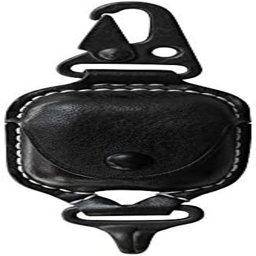

In [4]:
from PIL import Image
import io as _io

row = cached.take(1)[0]
print("id:        ", row["id"])
print("split:     ", row["split"])
print("title:     ", row["title"][:90])
print("teacher:   ", _strip_code_fence(row["raw_output"])[:240])
img = Image.open(_io.BytesIO(row["image_bytes"]))
img.thumbnail((256, 256))
img

## Build SFT examples

Apply `BuildSFTExample` to each split. This produces fixed-shape numpy
columns (`input_ids`, `labels`, `attention_mask`, `pixel_values`,
`image_grid_thw`) that Ray Data will stream into the trainer.

In [5]:
build_kwargs = dict(
    fn_constructor_kwargs={
        "model_id": STUDENT_MODEL_ID,
        "max_length": MAX_SEQ_LEN,
        "min_pixels": MIN_PIXELS,
        "max_pixels": MAX_PIXELS,
    },
    num_cpus=2,
    concurrency=4,
)

# Repartition before BuildSFTExample so the OutputSplitter at the trainer
# end has multiple blocks to balance across ranks. The smoke cache parquet
# is a single block; without this, OutputSplitter[split(2, equal=True)] can
# stall one rank waiting for the splitter to materialize, which on FSDP
# manifests as a NCCL collective hang at the first all-gather.
train_ds = (cached.filter(lambda r: r["split"] == "train")
                  .repartition(NUM_WORKERS_SMOKE * 2)
                  .map(BuildSFTExample, **build_kwargs))
val_ds = (cached.filter(lambda r: r["split"] == "val")
                .repartition(NUM_WORKERS_SMOKE * 2)
                .map(BuildSFTExample, **build_kwargs))

# Inspect one tokenized example. The shapes here drive every batching
# decision in the trainer; if anything's variable across rows, training will
# fail on the first stack() call.
example = train_ds.take(1)[0]
for k, v in example.items():
    if hasattr(v, "shape"):
        print(f"  {k:18} shape={tuple(v.shape)}  dtype={v.dtype}")
    else:
        print(f"  {k:18} = {v!r}")

# Loss-mask sanity check: assistant tokens are non-(-100), prefix tokens are
# all -100. The fraction non-masked ≈ length(target_json) / MAX_SEQ_LEN.
import numpy as np
labels = example["labels"]
n_loss_tokens = int((labels != -100).sum())
print(f"\nloss-mask: {n_loss_tokens}/{len(labels)} tokens contribute to loss "
      f"({100 * n_loss_tokens / len(labels):.1f}%)")

2026-05-04 14:15:35,342	WARNING util.py:624 -- The argument ``concurrency`` is deprecated in Ray 2.51. Please specify argument ``compute`` instead. For more information, see https://docs.ray.io/en/master/data/transforming-data.html#stateful-transforms.
2026-05-04 14:15:35,346	WARNING util.py:624 -- The argument ``concurrency`` is deprecated in Ray 2.51. Please specify argument ``compute`` instead. For more information, see https://docs.ray.io/en/master/data/transforming-data.html#stateful-transforms.
2026-05-04 14:15:35,349	INFO logging.py:392 -- Registered dataset logger for dataset dataset_73_0
2026-05-04 14:15:35,354	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_73_0. Full logs are in /tmp/ray/session_2026-05-04_10-43-39_675601_3151/logs/ray-data
2026-05-04 14:15:35,355	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_73_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[ReadFiles] -> TaskPoolMapOperator[Fi

(autoscaler +15s) Tip: use `ray status` to view detailed cluster status. To disable these messages, set RAY_SCHEDULER_EVENTS=0.
(autoscaler +15s) [autoscaler] [1xL4:8CPU-32GB] Attempting to add 1 node to the cluster (increasing from 0 to 1).
(autoscaler +15s) [autoscaler] [1xL4:8CPU-32GB|g6.2xlarge] [us-west-2b] [on-demand] Launched 1 instance.


(MapWorker(Map(BuildSFTExample)) pid=150541) The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
2026-05-04 14:15:45,667	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_73_0 =======
2026-05-04 14:15:45,667	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-04 14:15:45,668	INFO logging_progress.py:227 -- Active & requested resources: 1/8 CPU, 0.0B/6.7GiB object store (pending: 8 CPU)
2026-05-04 14:15:45,669	INFO logging_progress.py:181 -- 
2026-05-04 14:15:45,669	INFO logging_progress.py:231 -- ListFiles: 0/1
2026-05-04 14:15:45,670	INFO logging_progress.py:233 --   Tasks: 1; Actors: 0; Queued blocks: 0 (0.0B); Resources: 1.0 CPU

(autoscaler +2m10s) [autoscaler] Cluster upscaled to {16 CPU, 1 GPU}.


2026-05-04 14:17:36,516	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_73_0 =======
2026-05-04 14:17:36,517	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-04 14:17:36,518	INFO logging_progress.py:227 -- Active & requested resources: 9/8 CPU, 0.0B/6.7GiB object store
2026-05-04 14:17:36,518	INFO logging_progress.py:181 -- 
2026-05-04 14:17:36,519	INFO logging_progress.py:231 -- ListFiles: 0/1
2026-05-04 14:17:36,520	INFO logging_progress.py:233 --   Tasks: 1; Actors: 0; Queued blocks: 0 (0.0B); Resources: 1.0 CPU, 0.0B object store
2026-05-04 14:17:36,520	INFO logging_progress.py:231 -- ReadFiles: 0/1
2026-05-04 14:17:36,521	INFO logging_progress.py:233 --   Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 0.0B object store
2026-05-04 14:17:36,521	INFO logging_progress.py:231 -- Filter(<lambda>): 0/1
2026-05-04 14:17:36,522	INFO logging_progress.py:233 --   Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 0.0B object store

  input_ids          shape=(1024,)  dtype=int64
  labels             shape=(1024,)  dtype=int64
  attention_mask     shape=(1024,)  dtype=int64
  pixel_values       shape=(1296, 1176)  dtype=float32
  image_grid_thw     shape=(3,)  dtype=int64
  split              = 'train'

loss-mask: 112/1024 tokens contribute to loss (10.9%)


## Run training (smoke scale)

1 epoch, 2 workers, ~10 grad-accum steps. The same `train_loop_per_worker`
the production script runs — just driven by smaller config. Loads the model,
applies LoRA, FSDP-wraps, runs through the data shards, saves the adapter.

On 2× L4 this typically finishes in 8–12 minutes (most of it model load +
first-step compile). If it OOMs, drop `MAX_SEQ_LEN` to 1024 or set
`PER_DEVICE_BS_SMOKE = 1` and `GRAD_ACCUM_SMOKE = 8`.

In [6]:
trainer = TorchTrainer(
    train_loop_per_worker=train_loop_per_worker,
    train_loop_config={
        "model_id": STUDENT_MODEL_ID,
        "lr": LR_SMOKE,
        "num_epochs": NUM_EPOCHS_SMOKE,
        "per_device_bs": PER_DEVICE_BS_SMOKE,
        "grad_accum": GRAD_ACCUM_SMOKE,
        "warmup_ratio": WARMUP_RATIO_SMOKE,
        "weight_decay": 0.01,
        "lora_r": LORA_R,
        "lora_alpha": LORA_ALPHA,
        "lora_dropout": LORA_DROPOUT,
        "lora_target_modules": LORA_TARGET_MODULES,
        "train_size": n_train,
        "adapter_dir": SMOKE_ADAPTER_DIR,
        # Production uses 50; smoke has only ~10 grad steps total, so drop
        # to 5 to demonstrate that step-level checkpointing actually fires.
        # Expect ckpts at step 5 and step 10 (the latter coincides with the
        # end-of-epoch ckpt, so retention picks whichever has lower val_loss).
        "save_every_n_steps": 5,
        # Eval bs > train bs: no backward, no grad checkpoint tax. Smoke val
        # is ~8 rows, sharded across 2 workers → 4 rows each → exactly 1
        # batch per rank at eval_bs=4. Production uses 4 for the same reason.
        "eval_per_device_bs": 4,
        # Reproducibility: torch + cuda seeds offset per-rank, random/numpy
        # uniform. Without this, dropout and any python-side randomness drift
        # run-to-run even with identical data and config.
        "seed": 42,
    },
    scaling_config=ScalingConfig(
        num_workers=NUM_WORKERS_SMOKE,
        use_gpu=True,
        accelerator_type="L4",
        resources_per_worker={"GPU": 1, "CPU": 4},
        # PACK both workers onto the same node so FSDP all-gathers /
        # reduce-scatters use intra-node shared memory instead of crossing
        # the cluster network. Without this, a workspace with only
        # single-GPU L4 nodes available will land the 2 workers on
        # separate nodes; the first NCCL collective then either crawls
        # (10x+ slower per step) or hangs at all-gather. Requires a node
        # with >= num_workers GPUs (e.g. g6.12xlarge with 4x L4).
        # placement_strategy="PACK",
    ),
    run_config=RunConfig(
        storage_path=SMOKE_RUN_DIR,
        # num_to_keep=3 so all of (step5, step10, epoch0) can co-exist for
        # the demo — easy to inspect each in result.best_checkpoints.
        checkpoint_config=CheckpointConfig(
            num_to_keep=3,
            checkpoint_score_attribute="val_loss",
            checkpoint_score_order="min",
        ),
    ),
    datasets={"train": train_ds, "val": val_ds},
)
result = trainer.fit()
print(f"\n[done] metrics: {result.metrics}")
print(f"[done] best checkpoint: {result.checkpoint}")
print(f"[done] adapter: {SMOKE_ADAPTER_DIR}")

(TrainController pid=152042) [State Transition] INITIALIZING -> SCHEDULING.
(TrainController pid=152042) Attempting to start training worker group of size 2 with the following resources: [{'GPU': 1, 'CPU': 4, 'accelerator_type:L4': 0.001}] * 2


(autoscaler +2m30s) [autoscaler] [1xL4:8CPU-32GB] Attempting to add 1 node to the cluster (increasing from 1 to 2).
(autoscaler +2m35s) [autoscaler] [1xL4:8CPU-32GB|g6.2xlarge] [us-west-2b] [on-demand] Launched 1 instance.


(TrainController pid=152042) [FailurePolicy] RETRY
(TrainController pid=152042)   Source: controller
(TrainController pid=152042)   Error count: 1 (max allowed: inf)
(TrainController pid=152042) Error: Training failed due to controller error:
(TrainController pid=152042) The worker group startup timed out after 60.0 seconds waiting for 2 workers. Potential causes include: (1) temporary insufficient cluster resources while waiting for autoscaling (ignore this warning in this case), (2) infeasible resource request where the provided `ScalingConfig` cannot be satisfied), and (3) transient network issues. Set the RAY_TRAIN_WORKER_GROUP_START_TIMEOUT_S environment variable to increase the timeout.
(TrainController pid=152042) Traceback (most recent call last):
(TrainController pid=152042)   File "/home/ray/anaconda3/lib/python3.11/site-packages/ray/train/v2/_internal/execution/controller/controller.py", line 414, in _start_worker_group
(TrainController pid=152042)     self._worker_group = s

(autoscaler +4m25s) [autoscaler] Cluster upscaled to {24 CPU, 2 GPU}.


(RayTrainWorker pid=3684, ip=10.0.103.116) Setting up process group for: env:// [rank=0, world_size=2]
(raylet, ip=10.0.72.158) {"asctime":"2026-05-04 14:19:46,962","levelname":"E","message":"Delete runtime env failed","component":"raylet","filename":"worker_pool.cc","lineno":1862} [repeated 3x across cluster]
(TrainController pid=152042) Started training worker group of size 2: 
(TrainController pid=152042) - (ip=10.0.103.116, pid=3684) world_rank=0, local_rank=0, node_rank=0
(TrainController pid=152042) - (ip=10.0.72.158, pid=3139) world_rank=1, local_rank=0, node_rank=1
(TrainController pid=152042) [State Transition] SCHEDULING -> RUNNING.
(RayTrainWorker pid=3684, ip=10.0.103.116) [train] world_size=2, model=Qwen/Qwen2.5-VL-3B-Instruct, effective_batch=8, seed=42
(RayTrainWorker pid=3684, ip=10.0.103.116) `torch_dtype` is deprecated! Use `dtype` instead!
Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]
(RayTrainWorker pid=3139, ip=10.0.72.158) `torch_dtype` is deprecated! Us

...

(pid=154630)   *- Split Repartition:   0%|          | 0.00/1.00 [00:00<?, ? row/s]

(pid=154630) - Map(BuildSFTExample):   0%|          | 0.00/1.00 [00:00<?, ? row/s]

(pid=154630) - split(2, equal=True):   0%|          | 0.00/1.00 [00:00<?, ? row/s]

(MapWorker(Map(BuildSFTExample)) pid=4581, ip=10.0.72.158) The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
(SplitCoordinator pid=154630) ✔️  Dataset val_76_0 execution finished in 8.76 seconds
(RayTrainWorker pid=3139, ip=10.0.72.158) Reporting training result 3: TrainingReport(checkpoint=None, metrics={'epoch': 0, 'step': 10, 'val_loss': 0.38665562868118286}, validation=False)
(MapWorker(Map(BuildSFTExample)) pid=161237) The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To


[done] metrics: {'epoch': 0, 'step': 10, 'val_loss': 0.38665562868118286}
[done] best checkpoint: Checkpoint(filesystem=local, path=/mnt/cluster_storage/vlm-distillation-catalog-enrichment/qwen25vl_3b_enrichment_runs_smoke/ray_train_run-2026-05-04_14-17-47/checkpoint_2026-05-04_14-31-01.420711)
[done] adapter: /mnt/cluster_storage/vlm-distillation-catalog-enrichment/qwen25vl_3b_enrichment_lora_smoke


## Verify the adapter

Confirm the saved files are what we expect (`adapter_config.json` + adapter
weights). Skips actually loading the 3B base model — that would re-download
and burn another ~5 minutes. The full inference test belongs in the
downstream batch / serve script with the adapter swapped in.

In [7]:
import json as _json

files = sorted(os.listdir(SMOKE_ADAPTER_DIR))
print("adapter directory contents:")
for f in files:
    p = os.path.join(SMOKE_ADAPTER_DIR, f)
    size_mb = os.path.getsize(p) / 1e6
    print(f"  {f:40} {size_mb:>8.2f} MB")

with open(os.path.join(SMOKE_ADAPTER_DIR, "adapter_config.json")) as fh:
    adapter_cfg = _json.load(fh)
print("\nadapter_config.json (key fields):")
for k in ("r", "lora_alpha", "lora_dropout", "target_modules",
         "task_type", "base_model_name_or_path"):
    print(f"  {k:28} = {adapter_cfg.get(k)!r}")

adapter directory contents:
  README.md                                    0.01 MB
  adapter_config.json                          0.00 MB
  adapter_model.safetensors                   74.41 MB

adapter_config.json (key fields):
  r                            = 16
  lora_alpha                   = 32
  lora_dropout                 = 0.05
  target_modules               = ['up_proj', 'o_proj', 'gate_proj', 'q_proj', 'k_proj', 'v_proj', 'down_proj']
  task_type                    = 'CAUSAL_LM'
  base_model_name_or_path      = 'Qwen/Qwen2.5-VL-3B-Instruct'


(TrainController pid=152042) [State Transition] SHUTTING_DOWN -> FINISHED.


(autoscaler +19m55s) [autoscaler] Downscaling node i-01de46080421a8483 (node IP: 10.0.72.158) due to node idle termination.
(autoscaler +19m55s) [autoscaler] Downscaling node i-0614be572a9b517fe (node IP: 10.0.103.116) due to node idle termination.
(autoscaler +19m55s) [autoscaler] Cluster resized to {8 CPU, 0 GPU}.


## Next steps

If everything above ran clean, submit the full 10k-row training as an
Anyscale Job:

```bash
anyscale job submit --config-file job_config.yaml \
  --entrypoint "python scripts/run_finetune_vlm_enrichment_3b.py" \
  --env HF_TOKEN=$HF_TOKEN
```

Then load the adapter into the existing inference pipeline:

```python
from peft import PeftModel
from transformers import Qwen2_5_VLForConditionalGeneration

base = Qwen2_5_VLForConditionalGeneration.from_pretrained(STUDENT_MODEL_ID)
model = PeftModel.from_pretrained(base, ADAPTER_OUTPUT_DIR)
```

Or attach via vLLM in `run_enc_vlm_batch_emb_enrich_3b.py` /
`run_vlm_online_search_3b.py`:

```python
engine_kwargs={
    ...,
    "enable_lora": True,
    "lora_modules": [{"name": "enrich", "path": ADAPTER_OUTPUT_DIR}],
}
```